In [2]:
%matplotlib inline
import os
from glob import glob
from os.path import join as pjoin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
single_day_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250826"
rawPath = single_day_path
processPath = os.path.join(single_day_path, "process")

items = glob(os.path.join(rawPath, '202?????-??????-4*'))
experiments = list(set([os.path.basename(item)[:15] for item in items]))
print("Experiments found:", experiments)

for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")

velocity_path = glob(os.path.join(rawPath, '*-??????.csv'))[0]
print(velocity_path)
filename = pjoin(mergePath, experiment[:8] + ".h5")
print(filename)
    

Experiments found: ['20250826-200618']
/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250826/20250826-200618.csv
/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250826/process/20250826-200618-wfield/20250826.h5


In [16]:
def cal_velocity(even_data, step=100, window=1000):
    '''
    Calculate the speed of a motor encoder based on wave_A and wave_B channels
    When the codewheel rotates in the clockwise direction (as viewed from the 
    encoder end of the motor), channel A will lead channel B. If the codewheel 
    rotates in the counterclockwise direction, channel B will lead channel A.
    step: the step to measure the speed, default is 100
    window: the window size to calculate the speed, default is 1000

    '''

    cpr = 200
    diammeter = 2.54 # cm
    split_index = np.arange(0, even_data.shape[0], step)
    # split_index = np.append(split_index, even_data.shape[0])

    velocity = np.zeros((split_index.size-1))
    for i in range(split_index.size-1):
        wave_A = even_data[split_index[i]:split_index[i]+window, 1]
        wave_B = even_data[split_index[i]:split_index[i]+window, 2]
        raise_A = np.where(np.diff(wave_A) == 1)[0]
        count = 0
        for j in range(raise_A.size):
            if wave_B[raise_A[j]] == 0:
                count += 1
            else:
                count -= 1
        velocity[i] = (count / cpr * np.pi * diammeter)
        
    return velocity

In [19]:
velocity_data = pd.read_csv(velocity_path, header=None).values
n_tif = len(os.listdir(glob(os.path.join(rawPath, '*-470'))[0]))
event_frame_rate = np.round(len(velocity_data) / n_tif).astype(int)
print('event-frame-rate:', event_frame_rate)

event-frame-rate: 100


In [20]:
step = 100
velocity_ls = []
window = 1000

In [21]:
if event_frame_rate == 100:
        velocity = cal_velocity(velocity_data, step=100, window=1000)
        velocity_ls.append(velocity)

(34367,) 34367


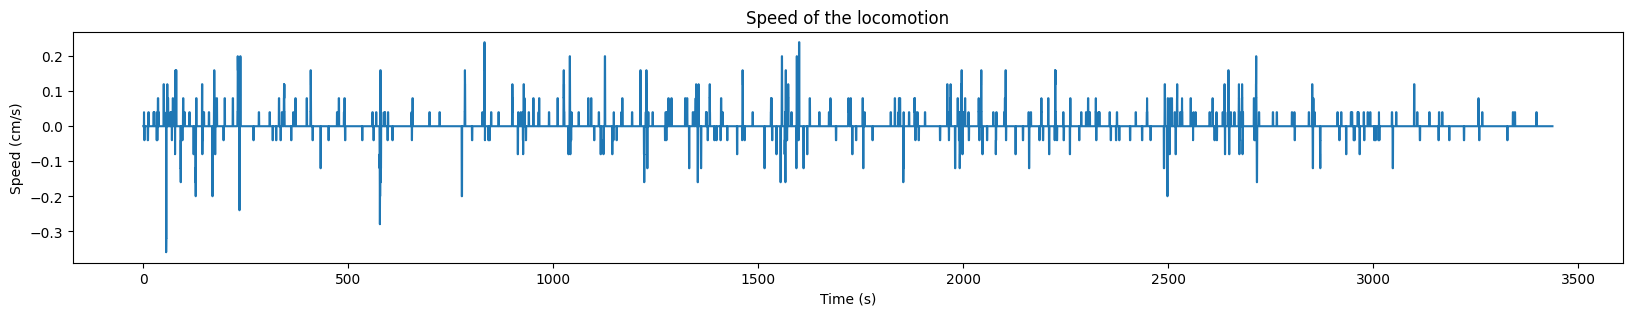

In [22]:

fig, ax = plt.subplots(figsize=(20, 3))
x = np.arange(0, len(velocity), step*0.01)
print(x.shape, len(velocity))
ax.plot(x/10, velocity)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Speed (cm/s)')
plt.title('Speed of the locomotion')
plt.show()

In [34]:
import h5py
trial_timestamp = []
with h5py.File(filename, 'r') as f:
    for trial_name in f.keys():  # 遍历所有 group
        ts = f[f"{trial_name}/trial_timestamp"][:]
        trial_timestamp.append(ts)

print("total trial num:", len(trial_timestamp))
print("the first trial timestamp:", trial_timestamp[0])

n_frames = velocity.shape[0] 
frame_times = np.arange(n_frames) / 10.0   # s
print(frame_times)



total trial num: 300
the first trial timestamp: [11.341  16.6212]
[0.0000e+00 1.0000e-01 2.0000e-01 ... 3.4364e+03 3.4365e+03 3.4366e+03]
